In [3]:
import matplotlib.pyplot as plt
import numpy as np
import math
import cmath

In [4]:
## LIFETIMES AND DECAY
k_s_tau = 8.958e-11
k_l_tau = 5.116e-8

gamma_s = 1/(k_s_tau)
gamma_l = 1/(k_l_tau)

delta_gamma = (gamma_s-gamma_l)*1e-9

delta_m = 5.293

## true epsilon

epsilon = cmath.rect(2.264e-3, math.radians(43.19))

In [5]:
def A_t(t):
    abs_e = abs(epsilon)
    phi   = cmath.phase(epsilon)

    exp_half = np.exp(0.5 * delta_gamma * t)
    exp_full = np.exp(delta_gamma * t)

    numer = 2.0 * abs_e * exp_half * np.cos(delta_m * t - phi)
    denom = 1.0 + (abs_e**2) * exp_full

    return  -1* numer / denom

A_t_vec = np.vectorize(A_t)

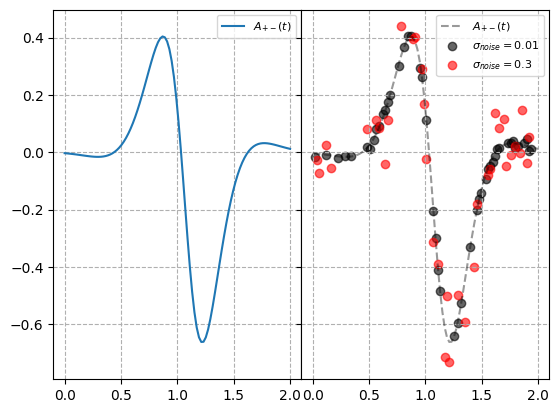

In [19]:
N = 100
tmax = 2

time_array = np.linspace(0, 2, N)
A_true  = A_t_vec(time_array)


fig = plt.figure()
gs = fig.add_gridspec(1,2, hspace=0, wspace=0)
ax = gs.subplots(sharex='col', sharey='row')


ax[0].plot(time_array, A_true, label=r"$A_{+-}(t)$")
ax[0].legend(fontsize=8)
ax[0].grid(True, linestyle='--')

time_event = time_array[np.random.uniform(0,1,N)>0.6]
noise = np.random.normal(0, 0.01, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

ax[1].plot(time_array, A_true, label=r"$A_{+-}(t)$", linestyle='--', c='black', alpha=0.4)
ax[1].scatter(time_event, A_measured, c='black', alpha=0.6, label=r"$\sigma_{noise}=0.01$")

time_event = time_array[np.random.uniform(0,1,N)>0.6]
noise = np.random.normal(0, 0.1, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

ax[1].scatter(time_event, A_measured, c='red', alpha=0.6, label=r"$\sigma_{noise}=0.3$")
ax[1].legend(fontsize=8)
ax[1].grid(True, linestyle='--')

plt.show()
